In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

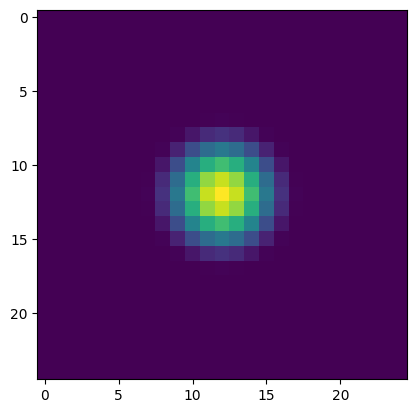

In [6]:
N = 25
ks = [
    ((N//2, N//2), 4.0),
    # ((N//1.25, N//1.25), 5.0),
    # ((N//4, N//4), 3.0)
]

def norm(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def f_inner(r, R):
    return -.4444 * (r ** 6) / (R ** 6) + 1.8888 * (r ** 4) / (R ** 4) - 2.4444 * (r ** 2) / (R ** 2) + 1.0

def f(ks, p):
    f_val = 0
    for k, R in ks:
        r = norm(k, p)
        R_hat = R * R / 3.0
        if r <= R_hat:
            f_val += f_inner(r, R_hat)
    return f_val * 100

def plot(N, ks):
    grid = np.zeros((N, N))
    for x in range(N):
        for y in range(N):
            grid[x,y] += f(ks, (x,y))
    return grid

grid = plot(N, ks)

plt.imshow(grid)
plt.show()


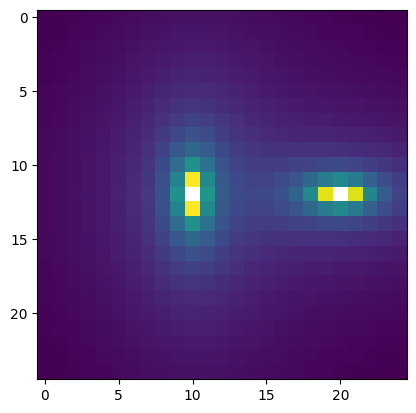

In [48]:
def g(a, b, R):
    d = (((a[0]-b[0])**2)/R[0] + ((a[1]-b[1])**2)/R[1])**.5
    if d == 0:
        return +np.inf
    else:
        return 1/d

def f(ks, p):
    f_val = 0
    for k, R in ks:
        f_val += g(k, p, R)
    return f_val

def plot(N, ks):
    grid = np.zeros((N, N))
    for x in range(N):
        for y in range(N):
            grid[x,y] += f(ks, (x,y))
    return grid

N = 25
ks = [
    ((N//2, N//2.5), (4.0, 1.0)),
    ((N//2, N//1.25), (1.0, 4.0))
]


grid = plot(N, ks)

plt.imshow(grid)
plt.show()
